# 1. Sarsa with value function approximation

In [ ]:
# SARSA algorithm with value function approximation

> Value Function Approximation (VFA) is a technique in Reinforcement Learning (RL) used to estimate the value function when the state space or state–action space is too large or continuous to store values in a table.

- Value function approximation represents the value function using a parameterized function instead of a lookup table.

- Instead of storing: $V(s)$
for every state $s$, we approximate it as: $V(s)≈V\textasciicircum(s,w)$

where:
  - $V\textasciicircum(s,w)$ = approximated value function
  - $w$ = learnable parameters (weights)
Similarly for action-value functions:
  - $Q(s,a)≈Q\textasciicircum(s,a,w)$

In [ ]:
## Setup FrozenLake environment

In [1]:
from frozen_lake_environment import generate_grid_randomly, FrozenLakeEnvironment, State
import numpy as np 
from matplotlib import pyplot
from visual_utils import render_policy_and_value, animate_policy_value_video, plot_trajectory_history

In [2]:
import os
print(os.path.exists("/System/Library/Fonts/Apple Color Emoji.ttc")) 


True


In [3]:
# lake_grid =generate_grid_randomly(3, 3, 1)
lake_grid = [['F', 'F', 'F'],
             ['F', 'H', 'F'],
             ['F', 'F', 'G']]

reward_points = {
    "S": 0,
    "G": 10,
    "F": 0,
    "H": 0
}

In [4]:
frozen_lake = FrozenLakeEnvironment(grid=lake_grid,
                                    reward_points=reward_points,
                                    slippery=True)

In [5]:
## SARSA algorithm with value function approximation

## Comparision between SARSA value function approximation and SARSA without value function approximation

- **Concept type:**
  - value function: A learning method used to estimate value functions by updating estimates using bootstrapping.
  - Value Function Approximation: A representation method used to approximate value functions when the state space is too large.

- **Purpose:**
  - value function: Focuses on how the value function is updated using the TD error.
  - Value Function Approximation: Focuses on how the value function is represented, often using parameterized functions.

- **State space handling:**
  - value function: Works well for small or tabular state spaces.
  - Value Function Approximation: Used when state spaces are large or continuous.

- **Representation of value function:**
  - value function: Typically uses a table of values for each state or state-action pair.
  - Value Function Approximation: Uses functions such as linear models, neural networks, or other parameterized models.

- **Scalability:**
  - value function: Limited scalability when using tabular representation.
  - Value Function Approximation: Scales better to high-dimensional or continuous environments.

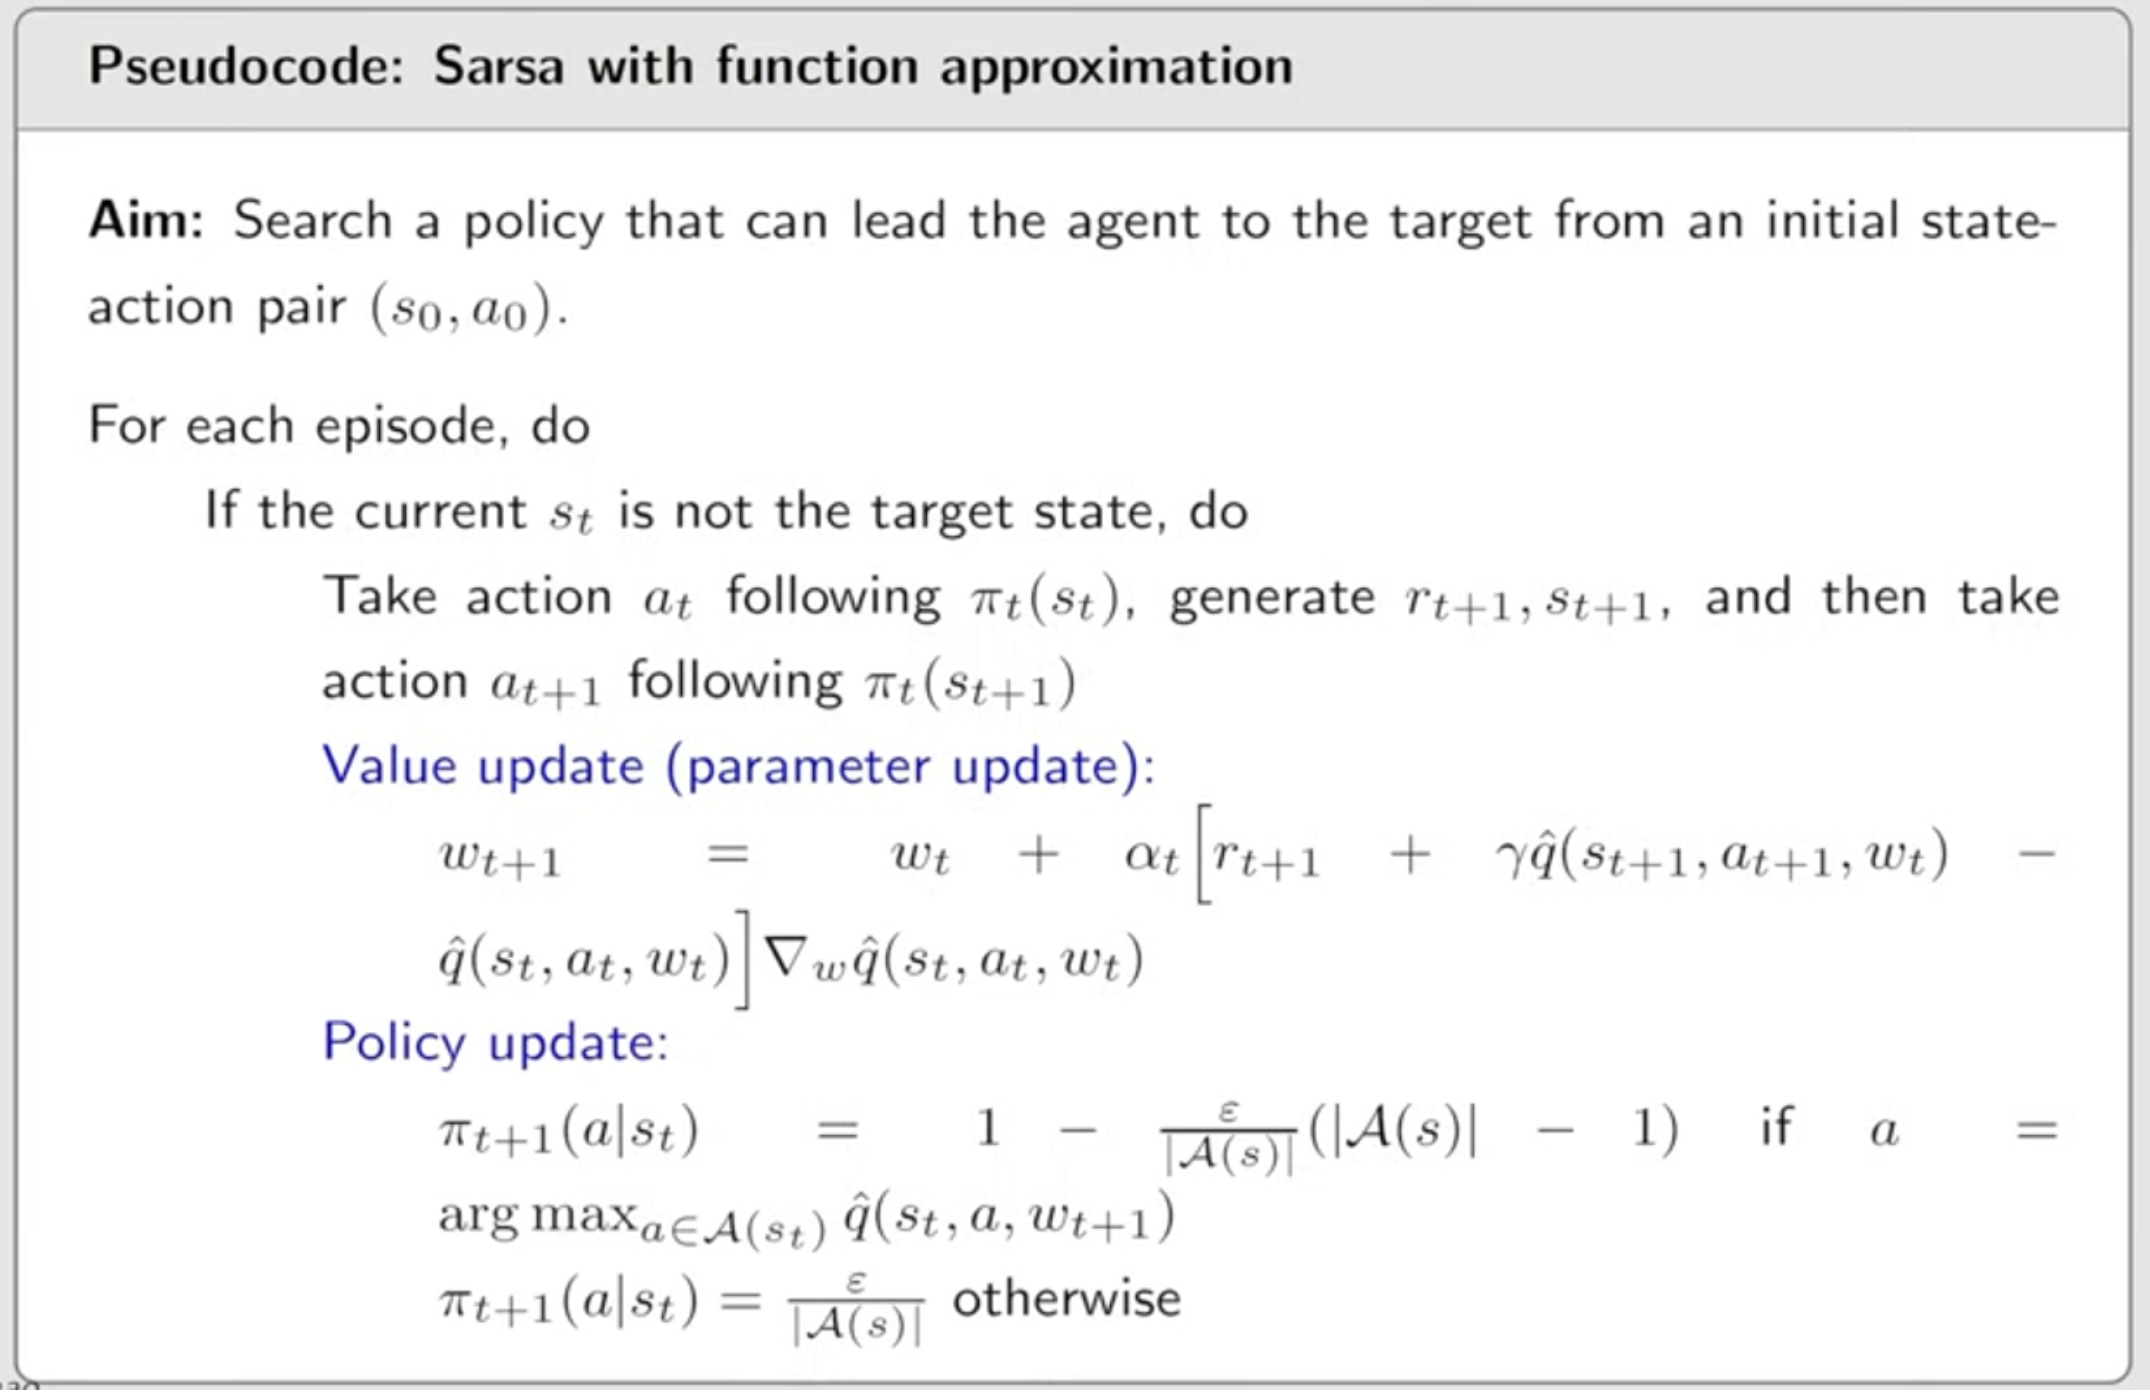

We can represent the value function $\hat{q}(s_t, a_t, w_t)$ as a linear combination of the state feature $s_t$,
   $$\hat{q}(s_t, a_t, w_t) = X(s_t, a_t)^T . W_t$$
   In general,
      $$\hat{q}(s, a, w) = X^T . W$$
      
So the derivative of $\hat(q)$ w.r.t $W$ is
$$ \nabla_wq = \frac{d (X^T . W)}{dW}$$
$$ \nabla_wq = X^T . \frac{dW}{dW}$$
$$ \nabla_wq = X$$

In [6]:
import random

In [7]:
def get_approx_Qsa(W, state, action, env):
    phi_s_a = state.get_one_hot_encoding(action,
                                         env.n_states,
                                         env.n_actions) # state-action feature vector
            
    Q_s_a = np.dot(phi_s_a, W) # action value of the given state-action pair
    return Q_s_a


def get_Q_table(W, env):
    states = [State(s_idx, env.n_cols) for s_idx in range(env.n_states)]
    Q = np.zeros((env.n_states, env.n_actions), dtype=np.int16)
    for s in states:
        for a in env.all_action_idx:
            Q[s.idx][a] = get_approx_Qsa(W, s, a, env)
    return Q

In [8]:
def epsilon_greedy_policy(W, state, env, epsilon=0.2):
    actions = env.all_action_idx    
    if random.random() < epsilon:
        return random.choice(actions) # <---- exploration
    else:
        action_values = []
        for a in actions:
            Q_s_a = get_approx_Qsa(W, state, a, env)
            action_values.append(Q_s_a)
        return actions[np.argmax(action_values)] # <-- exploitation

In [9]:
def get_policy_table(W, env):
    states = [State(s_idx, env.n_cols) for s_idx in range(env.n_states)]
    policy = np.zeros(env.n_states, dtype=np.int16)
    for s in states:
        greedy_action = epsilon_greedy_policy(W, s, env, epsilon=0.0) # epsilon=0.0 -> greedy policy
        policy[s.idx] = greedy_action
    return policy

In [10]:
def run_episode(env, W, state, action, episode_idx, epsilon=0.3, alpha=0.1, gamma=0.1, verbose=0):
    step = 0
    trajectory = []
    while True:
        trajectory.append(state.coord)
        result = env.step(state, action)
        reward = result["reward"]

        next_state = result["new_state"]
        is_terminated = result["is_terminated"] # True if hole or goal ?

        next_action = epsilon_greedy_policy(W,
                                            next_state,
                                            env,
                                            epsilon)

        # --- update W --------------------
        # ---------------------------------
        encoded_s_a = state.get_one_hot_encoding(action,
                                         env.n_states,
                                         env.n_actions) # state-action feature vector
        
        q_s_a = get_approx_Qsa(W,
                           state,
                           action,
                           env)
        
        q_s_a_next = get_approx_Qsa(W,
                                next_state,
                                next_action,
                                env) 
        
        
        W += alpha * (reward + gamma*q_s_a_next - q_s_a)*encoded_s_a
        # ----------------------------------
        # ----------------------------------        

        prev_state = state
        state = next_state
        action = next_action
        
        if verbose == 1:
            print(f"step {step}: state: {prev_state.coord} -> Action: {action} -> Reward: {reward} -> Next state: {state.coord}")
        elif verbose == 2:
            policy = get_policy_table(W, env)
            env.render(policy, next_state, episode_idx, step, reward)
            
        if is_terminated:
            break
        step += 1
    trajectory.append(state.coord)
    
    return W, get_policy_table(W, env), trajectory

In [11]:
def run_sarsa_with_fa(env, n_episodes=500, epsilon=0.5, alpha=0.2, gamma=0.99, verbose=0):
    policy_history = []
    W_history = []
    trajectory_history = []

    n_features = env.n_states * env.n_actions
    W = np.zeros(n_features)

    for episode_idx in range(n_episodes):

        initial_state = env.find('S')
        initial_action = 2 #randomly picked

        W, greedy_policy, trajectory = run_episode(env,
                                       W, 
                                       initial_state,
                                       initial_action, 
                                       episode_idx,
                                       epsilon=epsilon,
                                       alpha=alpha,
                                       gamma=gamma,
                                       verbose=verbose)
        policy_history.append(greedy_policy)
        W_history.append(W)
        trajectory_history.append(trajectory)
        
    return W, {"policy_history": policy_history, 
                "W_history": W_history, 
                "trajectory_history": trajectory_history}

In [12]:
lake_grid = [["F", "F", "S", "F"],
             ["F", "F", "H", "F"],
             ["F", "F", "F", "G"],
             ["F", "H", "F", "F"]]
# lake_grid = [["F", "F", "S", "F", "H"],
#              ["F", "F", "H", "F", "F"],
#              ["F", "F", "F", "G", "F"],
#              ["F", "H", "F", "F", "F"],
#              ["H", "H", "F", "F", "F"]]

reward_points = {
    "S": 0,
    "G": 10,
    "F": 0,
    "H": 0
}
frozen_lake = FrozenLakeEnvironment(grid=lake_grid,
                                    reward_points=reward_points,
                                    slippery=True)

In [13]:
W, history = run_sarsa_with_fa(frozen_lake, n_episodes=5000, verbose=0)

In [14]:
policy = history["policy_history"][-1] 

In [15]:
policy

array([2, 3, 2, 1, 3, 3, 0, 1, 3, 2, 2, 0, 3, 0, 0, 3], dtype=int16)

In [16]:
W

array([2.66588834, 2.19912576, 2.70734854, 2.63176187, 2.48448109,
       2.22357228, 2.51748902, 2.93025866, 3.01152824, 0.62146509,
       4.23591355, 2.66588801, 3.34302615, 5.80156674, 5.33148388,
       5.26781278, 2.15871963, 1.30704313, 2.0559257 , 2.39771954,
       1.49541586, 1.24913096, 0.63137692, 2.98424149, 0.        ,
       0.        , 0.        , 0.        , 0.38108852, 9.20145892,
       4.98886772, 5.63677507, 1.52396192, 0.94929273, 1.24506505,
       1.97050097, 1.45796986, 0.53909315, 1.51462584, 1.21222625,
       0.7610513 , 1.44346988, 7.58426818, 2.36780013, 0.        ,
       0.        , 0.        , 0.        , 0.46616486, 0.30407372,
       0.19904354, 0.89558783, 0.        , 0.        , 0.        ,
       0.        , 0.52838749, 0.        , 0.        , 0.        ,
       0.1307759 , 0.        , 0.        , 2.        ])

In [17]:
Q = get_Q_table(W, frozen_lake)
Q

array([[2, 2, 2, 2],
       [2, 2, 2, 2],
       [3, 0, 4, 2],
       [3, 5, 5, 5],
       [2, 1, 2, 2],
       [1, 1, 0, 2],
       [0, 0, 0, 0],
       [0, 9, 4, 5],
       [1, 0, 1, 1],
       [1, 0, 1, 1],
       [0, 1, 7, 2],
       [0, 0, 0, 0],
       [0, 0, 0, 0],
       [0, 0, 0, 0],
       [0, 0, 0, 0],
       [0, 0, 0, 2]], dtype=int16)

In [18]:
def convert_1d_to_2d_policy(policy_1d, n_rows, n_cols):
    policy_2d = np.zeros((n_rows, n_cols),dtype=np.int16)

    for idx, value in enumerate(policy_1d):
        r, c = State(idx, n_cols).coord
        policy_2d[r][c] = value
    return policy_2d

In [19]:
policy_2d = convert_1d_to_2d_policy(policy, frozen_lake.n_rows, frozen_lake.n_cols)
policy_2d

array([[2, 3, 2, 1],
       [3, 3, 0, 1],
       [3, 2, 2, 0],
       [3, 0, 0, 3]], dtype=int16)

In [20]:
# Render policy and trajectory

In [21]:
import pandas as pd
from IPython.display import display

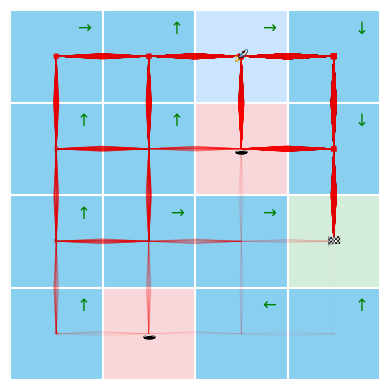

In [22]:
# render_policy_and_value(frozen_lake, policy, None)
plot_trajectory_history(frozen_lake,
                        history["trajectory_history"],
                        policy)

In [23]:
# Animate policy history

In [24]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

In [25]:
ani = animate_policy_value_video(frozen_lake, history["policy_history"][-10:])
HTML(ani.to_jshtml())

In [26]:
# Play with different grid setup

In [27]:
grid = generate_grid_randomly(4, 4, n_holes=4)
grid

[['F', 'F', 'H', 'F'],
 ['F', 'G', 'F', 'F'],
 ['F', 'F', 'H', 'H'],
 ['H', 'F', 'F', 'S']]

In [28]:
frozen_lake = FrozenLakeEnvironment(grid=grid,
                                    reward_points=reward_points,
                                    slippery=True)

In [29]:
Q, history = run_sarsa_with_fa(frozen_lake,
                               n_episodes=5000,
                               epsilon=0.1,
                               verbose=0)

In [30]:
policy = history["policy_history"][-1]

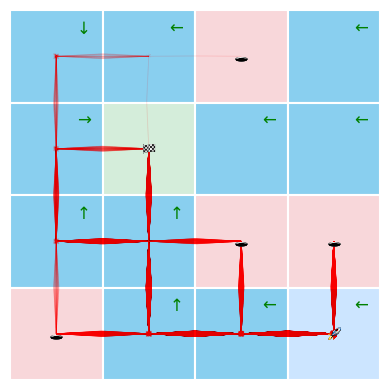

In [31]:
# render_policy_and_value(frozen_lake, policy, None)
plot_trajectory_history(frozen_lake,
                        history["trajectory_history"],
                        policy)